### Problem Definition
- **What problem are we solving?** Predicting which employees are likely to resign (attrition).
- **Why is this problem important?** Employee turnover is incredibly expensive for HR departments. Identifying flight risks early allows for retention interventions.
- **What type of ML problem is this?** Supervised Binary Classification.

---

### Dataset
- **What information does this dataset contain?** Employee satisfaction, salary, years at company, and role.
- **What is the target?** Attrition (Yes/No).

In [43]:
import pandas as pd

df = pd.read_csv('./data/HR-Employee-Attrition.csv')

In [44]:
import pandas as pd

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.isna().sum())
print(df[df.duplicated(keep=False)].count())

print('\nDuplicates')
df.drop_duplicates(inplace=True)
print(df[df.duplicated(keep=False)])

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

### Visualization
- **What does this graph show?** A Feature Importance plot.
- **What should the reader notice?** The reader should notice which HR metrics (e.g., MonthlyIncome, OverTime) are the strongest drivers of an employee quitting.

           Count  Percentage (%)
Attrition                       
No          1233       83.877551
Yes          237       16.122449


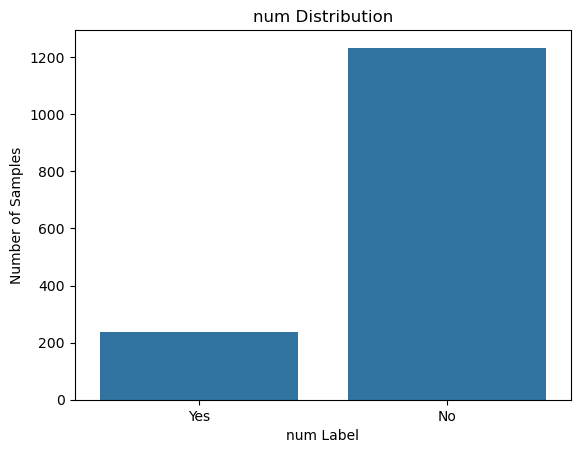

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['Attrition'].value_counts()
percentages = df['Attrition'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(imbalance_summary)

sns.countplot(x='Attrition', data=df)
plt.title('num Distribution')
plt.xlabel('num Label')
plt.ylabel('Number of Samples')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

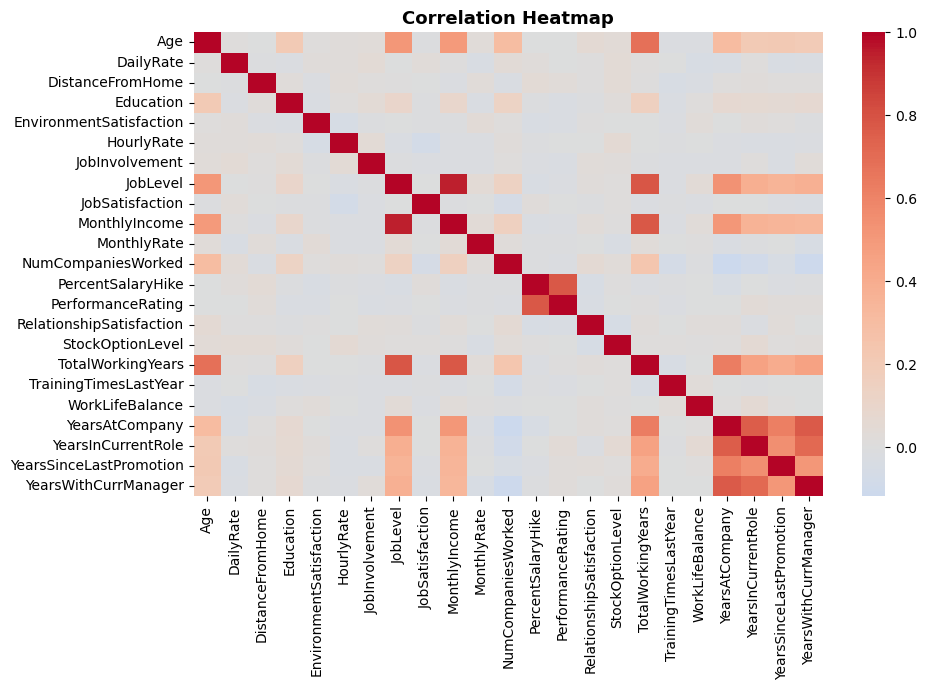

In [62]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include='number').corr(), fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [47]:
print((df['Age'] < 20).value_counts())


df['age_range'] = pd.cut(
    df['Age'], 
    bins=[0, 40, 55, 120], 
    labels=['adult', 'middle_age', 'senior'],
    include_lowest=True)

print(df[['Age', 'age_range']])

df.drop(
    columns=[
        "EmployeeCount",
        "StandardHours",
        "EmployeeNumber"
    ],
    inplace=True
)

Age
False    1453
True       17
Name: count, dtype: int64
      Age   age_range
0      41  middle_age
1      49  middle_age
2      37       adult
3      33       adult
4      27       adult
...   ...         ...
1465   36       adult
1466   39       adult
1467   27       adult
1468   49  middle_age
1469   34       adult

[1470 rows x 2 columns]


### Data Preprocessing
- **Encoding:** HR datasets are heavily categorical (Department, Job Role, Education Field). We heavily utilize One-Hot Encoding to prepare this for the model.

In [48]:
X = df.drop(columns='Attrition')
y = df['Attrition']

print(X.select_dtypes(include='number').skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)
# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
y_encoded = pd.get_dummies(y, drop_first=True)

Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, random_state=42, train_size=0.80, stratify=y)

### Model Selection
- **Why choose this algorithm?** Random Forests excel at complex tabular datasets. They build hundreds of independent Decision Trees and average their predictions (Bagging).
- **What are its strengths?** Highly resistant to overfitting and naturally calculates Feature Importance.

In [50]:
# Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
from sklearn.tree import DecisionTreeClassifier
# Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
decision_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
    ('model', DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
random_forest_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
    ('model', RandomForestClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

decision_model.fit(X_train, y_train.values.ravel())
random_forest_model.fit(X_train, y_train.values.ravel())


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2


### Evaluation
- **Why these metrics?** F1-Score is critical here. Predicting everyone will stay gives high accuracy, but fails the business objective of finding the flight risks.

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import pandas as pd

decision_preds = decision_model.predict(X_test)
random_forest_preds = random_forest_model.predict(X_test)

decision_prob = decision_model.predict_proba(X_test)[:, 1]
randome_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
decision_roc_auc = roc_auc_score(y_test, decision_prob,  multi_class='ovr', average='weighted')
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
random_forest_roc_auc = roc_auc_score(y_test, randome_forest_prob, multi_class='ovr', average='weighted')



models = {
    'Decision': decision_preds,
    'Randome_Forest': random_forest_preds
}

evaluation_data = []

for name, preds in models.items():
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
    f1 = f1_score(y_test, preds, average='weighted')
    cm = confusion_matrix(y_test, preds)
    
    evaluation_data.append({
        'Model Framework': name,
        'Accuracy': accuracy,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
    })

metrics_table = pd.DataFrame(evaluation_data)
metrics_table['ROC_AUC'] = [decision_roc_auc, random_forest_roc_auc]

print("Performance Metrics Comparison\n")
print(metrics_table[['Model Framework', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC_AUC']].to_markdown(index=False))


Performance Metrics Comparison

| Model Framework   |   Accuracy |   Precision |   Recall |   F1-Score |   ROC_AUC |
|:------------------|-----------:|------------:|---------:|-----------:|----------:|
| Decision          |   0.72449  |      0.7997 |   0.7245 |     0.7522 |  0.682488 |
| Randome_Forest    |   0.792517 |      0.8187 |   0.7925 |     0.8035 |  0.75519  |


In [52]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "decision_model": decision_model,
    "random_forest_model": random_forest_model
}

for name, model in models.items():

    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring='roc_auc_ovr_weighted',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)

print(cv_df)

                     Mean CV ROC-AUC  Std CV ROC-AUC
Model                                               
decision_model                0.7029          0.0417
random_forest_model           0.7783          0.0113


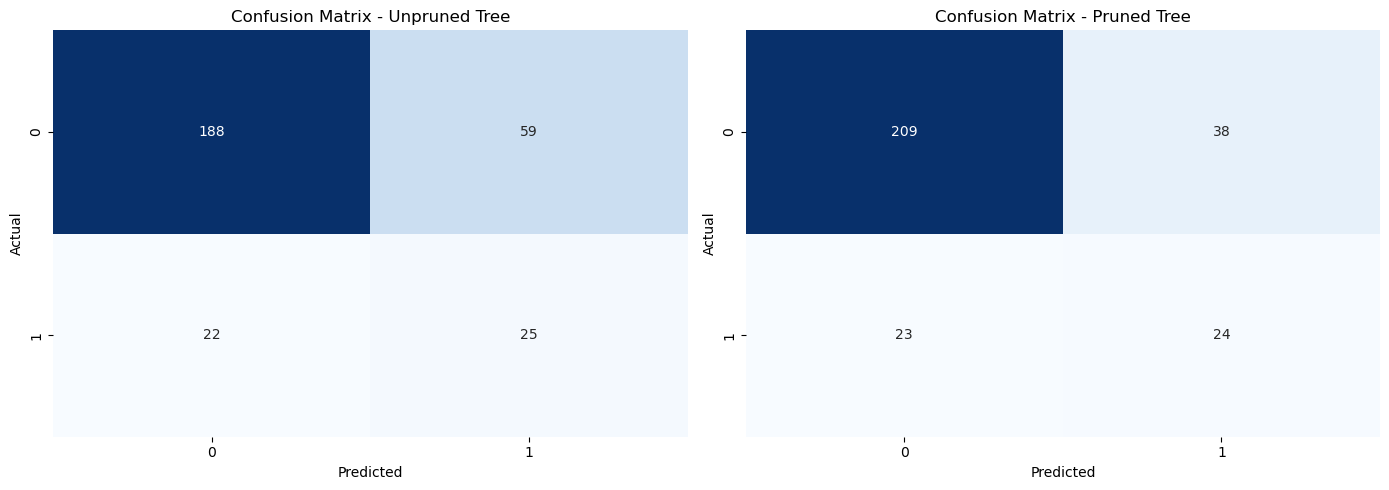

In [53]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

unpruned_cm = confusion_matrix(y_test, decision_preds)
pruned_cm = confusion_matrix(y_test, random_forest_preds)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    unpruned_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    cbar=False
)
ax[0].set_title("Confusion Matrix - Unpruned Tree")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels([0,1])
ax[0].set_yticklabels([0,1])

sns.heatmap(
    pruned_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1],
    cbar=False
)
ax[1].set_title("Confusion Matrix - Pruned Tree")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels([0,1])
ax[1].set_yticklabels([0,1])

plt.tight_layout()
plt.show()


### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

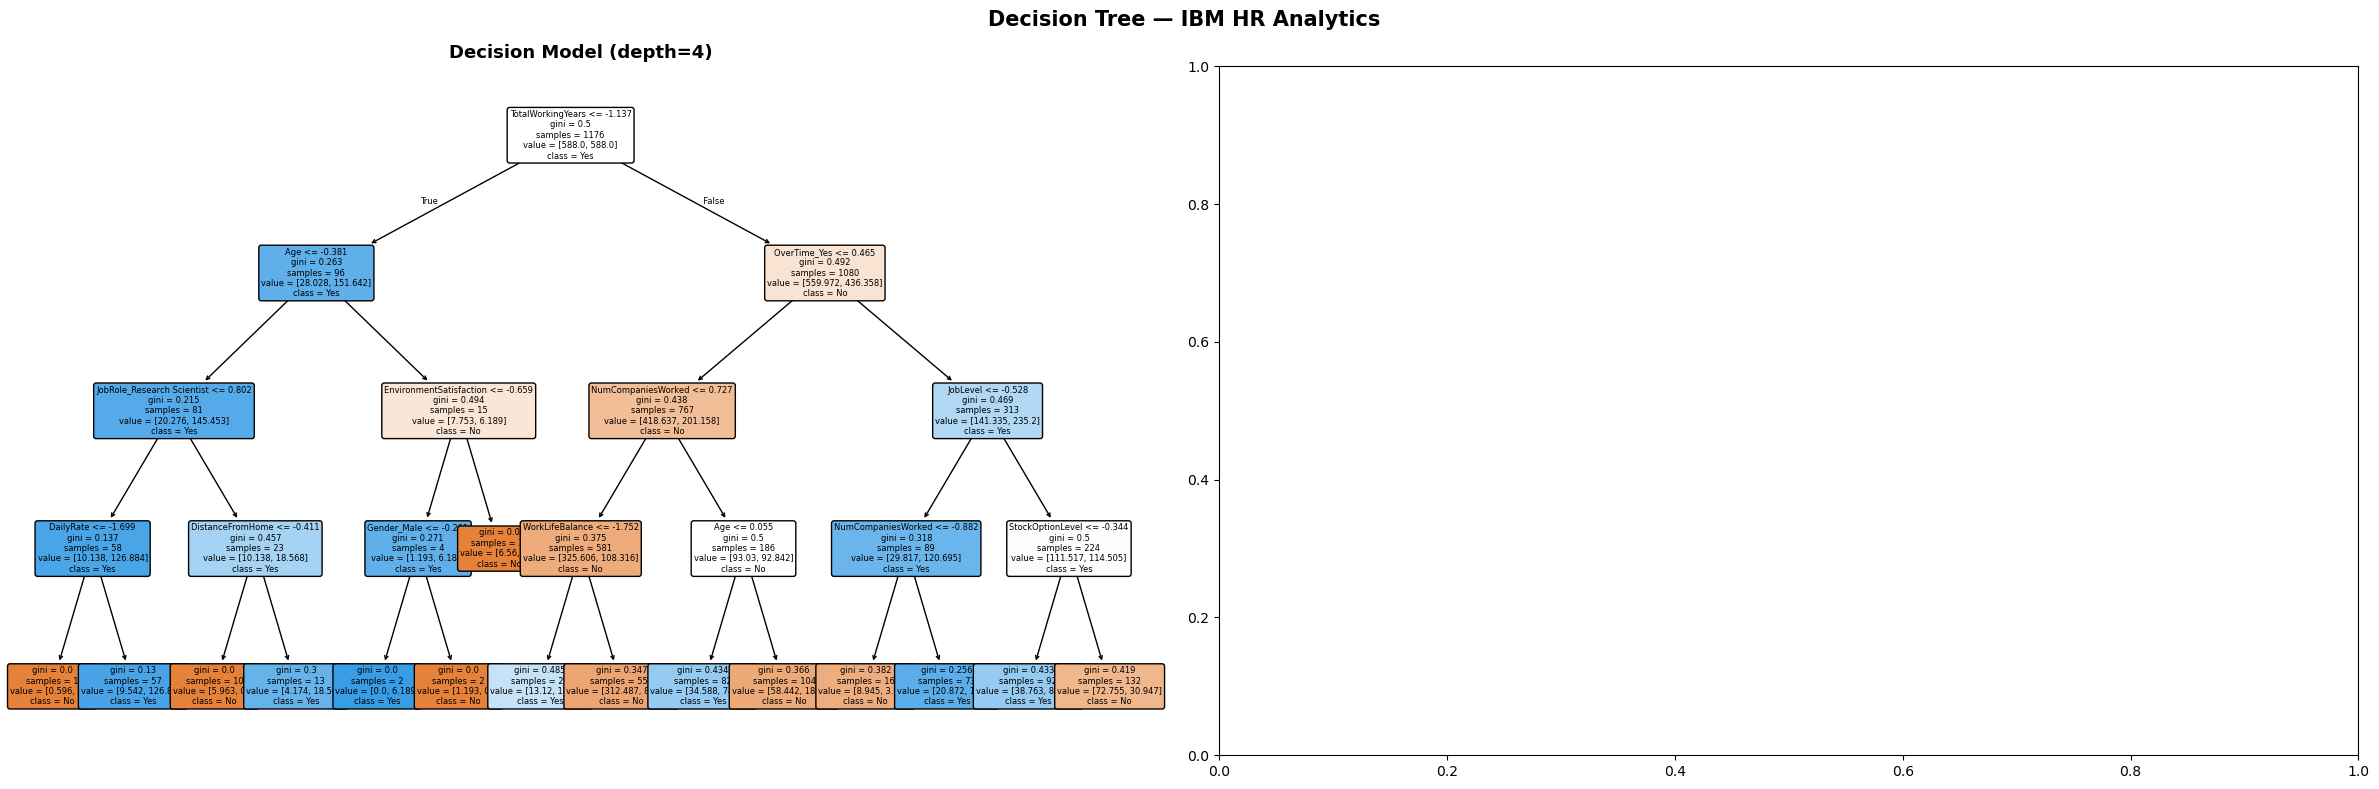

In [54]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

for ax, pipe, title in zip(
    axes,
    [decision_model],
    ['Decision Model (depth=4)']
):
    plot_tree(
        pipe.named_steps['model'],
        feature_names=X_encoded.columns,
        class_names=[str(c) for c in sorted(y.unique())],
        filled=True,
        rounded=True,
        fontsize=6,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Decision Tree — IBM HR Analytics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

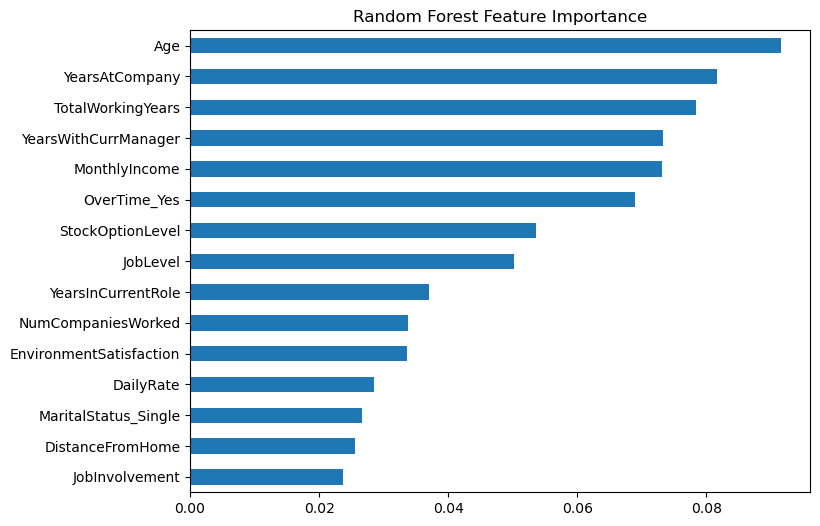

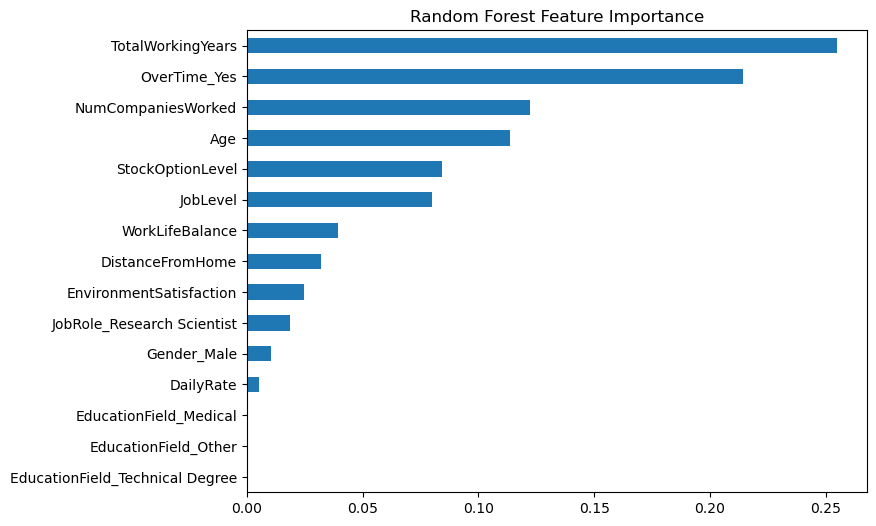

In [60]:
importance = pd.Series(
    random_forest_model.named_steps['model'].feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

importance.head(15).plot.barh(figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

importance = pd.Series(
    decision_model.named_steps['model'].feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

importance.head(15).plot.barh(figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Visualization Analysis: Feature Importance
- **Marking Values:** The longest bars at the top of the chart represent the features that drove the model's decision-making process the most.
- **Correct Interpretation:** If a feature has 0 importance, the tree/forest never used it to make a split. It can be safely dropped from the dataset.
- **How to Interpret:** The X-axis represents the magnitude of the feature's contribution (e.g., Gini impurity reduction) to the final predictions.
- **Common Mistakes:** Assuming a low feature importance means the feature is globally useless. It might just be heavily correlated with a higher-ranking feature that "stole" its importance.

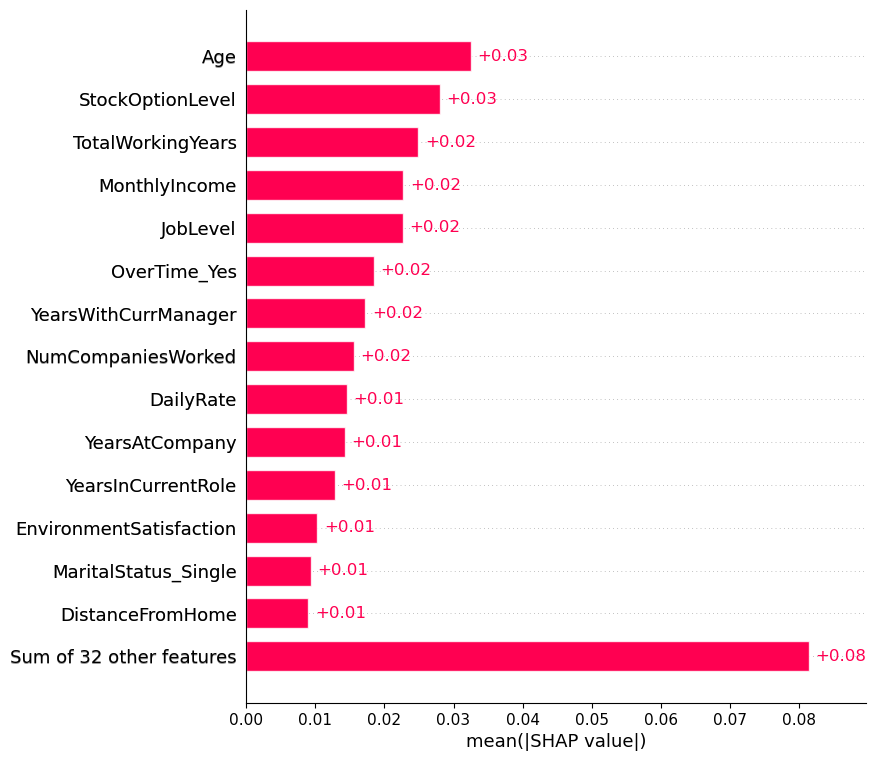

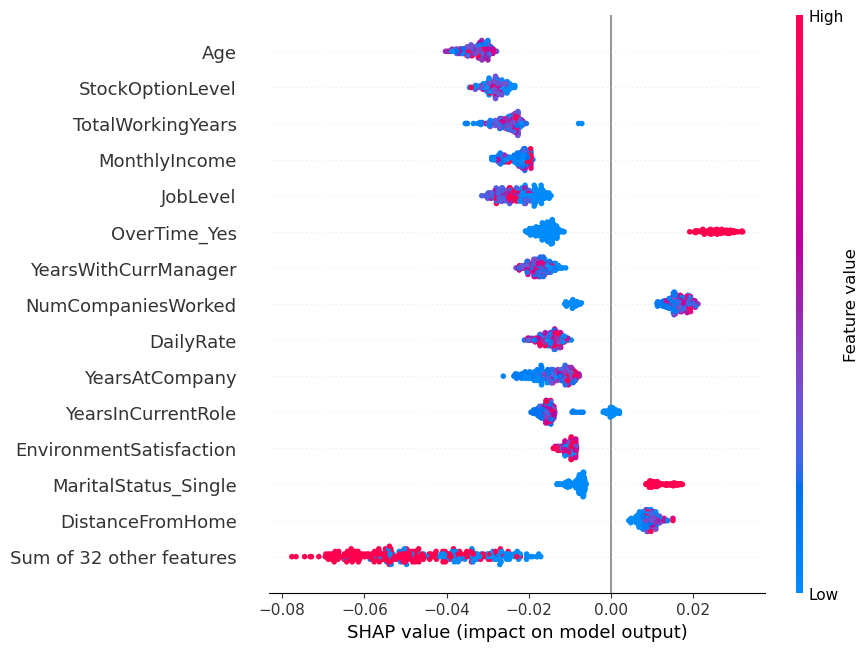

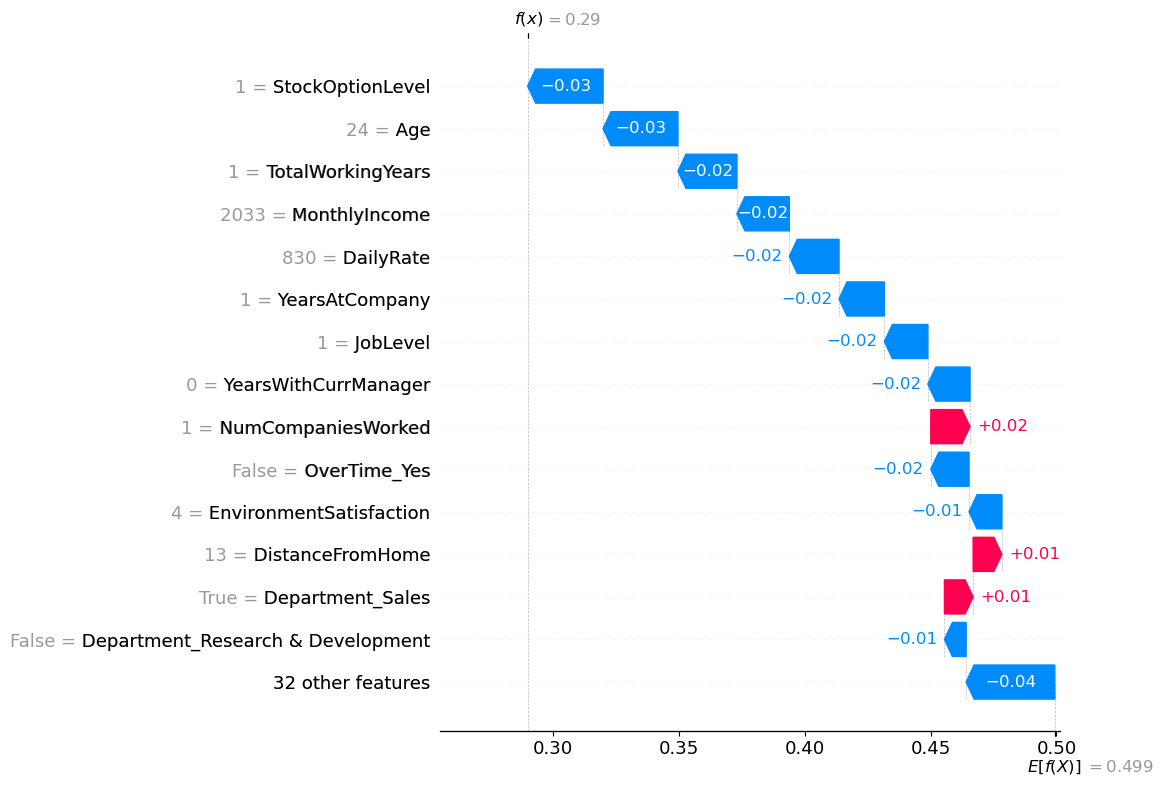

In [ ]:
import shap

rf = random_forest_model.named_steps["model"]

explainer = shap.Explainer(rf)

shap_values = explainer(X_test)

shap_yes = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=shap_values.data,
    feature_names=X_test.columns
)

shap.plots.bar(shap_yes, max_display=15)

shap.plots.beeswarm(shap_yes, max_display=15)

shap.plots.waterfall(shap_yes[0], max_display=15)

shap.initjs()
shap.plots.force(shap_yes[0])

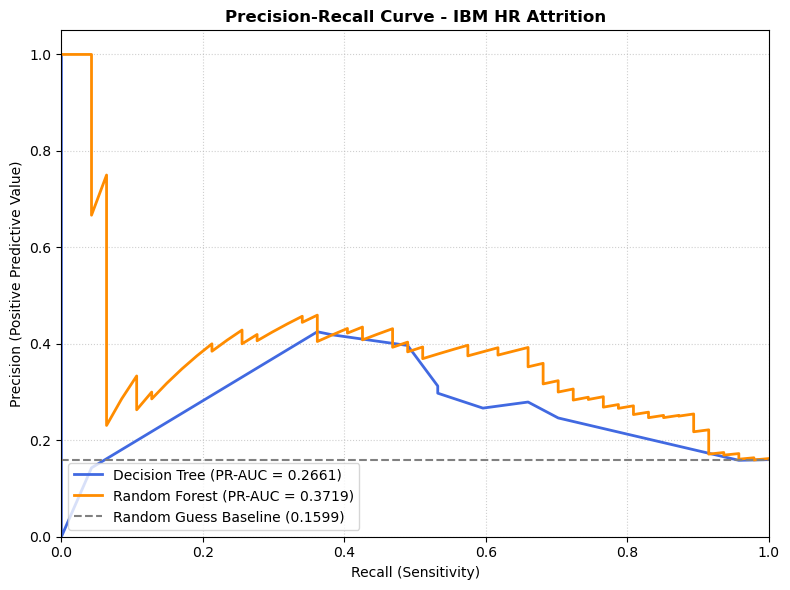

In [63]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

y_true = y_test.values.ravel()

decision_probs = decision_model.predict_proba(X_test)[:, 1]
random_forest_probs = random_forest_model.predict_proba(X_test)[:, 1]

# Decision Tree PR curve
dec_prec, dec_rec, _ = precision_recall_curve(y_true, decision_probs)
dec_pr_auc = auc(dec_rec, dec_prec)

# Random Forest PR curve
rf_prec, rf_rec, _ = precision_recall_curve(y_true, random_forest_probs)
rf_pr_auc = auc(rf_rec, rf_prec)

baseline_ratio = y_true.mean()

plt.figure(figsize=(8, 6))
plt.plot(dec_rec, dec_prec, label=f'Decision Tree (PR-AUC = {dec_pr_auc:.4f})',
         color='royalblue', lw=2)
plt.plot(rf_rec, rf_prec, label=f'Random Forest (PR-AUC = {rf_pr_auc:.4f})',
         color='darkorange', lw=2)
plt.axhline(y=baseline_ratio, color='grey', linestyle='--',
            label=f'Random Guess Baseline ({baseline_ratio:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve - IBM HR Attrition', fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

### Conclusion
- **Biggest takeaway:** Ensembles (Random Forest) drastically outperform single models on complex datasets.
- **Main limitation:** We lose the perfect interpretability of a single Decision Tree.